In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import os, random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm
from tqdm import tqdm
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('Imports done | CUDA:', torch.cuda.is_available())

Imports done | CUDA: True


In [2]:
# ============================================================
# CELL 2 — PATHS
# ============================================================
BASE    = '/kaggle/input/datasets/madhvii0911/uercccc/UERC26_Oriented/data/sequestered_anonymized'
IMG_DIR = os.path.join(BASE, '0')

print('Total images:', len(os.listdir(IMG_DIR)))

Total images: 1670


In [22]:
# ============================================================
# CELL 3 — CORRECT DATAFRAME + SPLIT
# ============================================================
all_files = sorted(os.listdir(IMG_DIR))

df_images = pd.DataFrame({
    'image'    : all_files,
    # Har 10 images = 1 person: 0001-0010 = person 0, 0011-0020 = person 1...
    'person_id': [i // 10 for i in range(len(all_files))]
})

print(f"Total images  : {len(df_images)}")
print(f"Total persons : {df_images['person_id'].nunique()}")
print(f"Images/person : {df_images.groupby('person_id').size().unique()}")
print(df_images.head(12))

# Person level 80/20 split
all_pids = df_images['person_id'].unique()
np.random.seed(SEED)
np.random.shuffle(all_pids)

split_idx = int(0.8 * len(all_pids))
train_df  = df_images[df_images['person_id'].isin(all_pids[:split_idx])].reset_index(drop=True)
val_df    = df_images[df_images['person_id'].isin(all_pids[split_idx:])].reset_index(drop=True)

print(f"\nTrain: {len(train_df)} images | {train_df['person_id'].nunique()} persons")
print(f"Val  : {len(val_df)} images | {val_df['person_id'].nunique()} persons")

Total images  : 1670
Total persons : 167
Images/person : [10]
        image  person_id
0   0001.webp          0
1   0002.webp          0
2   0003.webp          0
3   0004.webp          0
4   0005.webp          0
5   0006.webp          0
6   0007.webp          0
7   0008.webp          0
8   0009.webp          0
9   0010.webp          0
10  0011.webp          1
11  0012.webp          1

Train: 1330 images | 133 persons
Val  : 340 images | 34 persons


In [23]:
# ============================================================
# CELL 4 — DATASET + DATALOADERS
# ============================================================
class SiameseDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df         = df.reset_index(drop=True)
        self.img_dir    = img_dir
        self.transform  = transform
        self.person_ids = self.df['person_id'].unique()
        self.id2imgs    = self.df.groupby('person_id')['image'].apply(list).to_dict()

    def __len__(self):
        return len(self.df)

    def load(self, img_name):
        return Image.open(os.path.join(self.img_dir, str(img_name).strip())).convert('RGB')

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        target = random.randint(0, 1)

        try:
            img1 = self.load(row['image'])
        except:
            return self.__getitem__(random.randint(0, len(self.df)-1))

        if target == 1:
            img2_name = random.choice(self.id2imgs[row['person_id']])
        else:
            other     = [p for p in self.person_ids if p != row['person_id']]
            img2_name = random.choice(self.id2imgs[random.choice(other)])

        try:
            img2 = self.load(img2_name)
        except:
            return self.__getitem__(random.randint(0, len(self.df)-1))

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(target, dtype=torch.float32)


train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomGrayscale(p=0.1),
    transforms.ColorJitter(0.3, 0.3, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds     = SiameseDataset(train_df, IMG_DIR, train_tf)
val_ds       = SiameseDataset(val_df,   IMG_DIR, val_tf)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 42 | Val batches: 11


In [24]:
#============================================================
# CELL 5 — MODEL (ConvNeXt-Atto + MobileNetV3-Small + MobileNetV2) ~7M
# ============================================================
class TripleBackboneSiamese(nn.Module):
    def __init__(self, embed_dim=128, pretrained=True):
        super().__init__()

        # Backbone 1: ConvNeXt-Atto — ~3.7M
        self.convnext  = timm.create_model(
            'convnext_atto',        pretrained=pretrained, num_classes=0, global_pool='avg')
        cn_dim = self.convnext.num_features   # 320
#
        # Backbone 2: MobileNetV3-Small — ~1.5M
        self.mobilenet = timm.create_model(
            'mobilenetv3_small_100', pretrained=pretrained, num_classes=0, global_pool='avg')
        mn_dim = self.mobilenet.num_features  # 576

        # Backbone 3: MobileNetV2-100 — ~2.2M
        self.mobilenet2 = timm.create_model(
            'mobilenetv2_100',      pretrained=pretrained, num_classes=0, global_pool='avg')
        mn2_dim = self.mobilenet2.num_features  # 1280

        # Yeh line change karo — 320 + 1024 + 1280 = 2624
        total_dim = 320 + 1024 + 1280
        self.projector = nn.Sequential(
            nn.Linear(2624,256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256,128)
        )


    def encode(self, x):
        f1 = self.convnext(x)
        f2 = self.mobilenet(x)
        f3 = self.mobilenet2(x)
        if f1.dim() > 2: f1 = f1.flatten(1)
        if f2.dim() > 2: f2 = f2.flatten(1)
        if f3.dim() > 2: f3 = f3.flatten(1)
        f = torch.cat([f1, f2, f3], dim=1)
        return F.normalize(self.projector(f), p=2, dim=1)

    def forward(self, img1, img2):
        return self.encode(img1), self.encode(img2)


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = TripleBackboneSiamese(embed_dim=128, pretrained=True).to(DEVICE)

cn_p  = sum(p.numel() for p in model.convnext.parameters())   / 1e6
mn_p  = sum(p.numel() for p in model.mobilenet.parameters())  / 1e6
mn2_p = sum(p.numel() for p in model.mobilenet2.parameters()) / 1e6
pr_p  = sum(p.numel() for p in model.projector.parameters())  / 1e6
total = sum(p.numel() for p in model.parameters())            / 1e6

print(f'ConvNeXt-Atto     : {cn_p:.2f}M')
print(f'MobileNetV3-Small : {mn_p:.2f}M')
print(f'MobileNetV2-100   : {mn2_p:.2f}M')
print(f'Projector Head    : {pr_p:.2f}M')
print(f'----------------------------')
print(f'Total Params      : {total:.2f}M')
print(f'Device            : {DEVICE}')

ConvNeXt-Atto     : 3.37M
MobileNetV3-Small : 1.52M
MobileNetV2-100   : 2.22M
Projector Head    : 0.71M
----------------------------
Total Params      : 7.82M
Device            : cuda


In [25]:
def encode(self, x):
    f1 = self.convnext(x)
    f2 = self.mobilenet(x)
    f3 = self.mobilenet2(x)
    
    # Force 2D — (B, features)
    f1 = f1.flatten(1) if f1.dim() > 2 else f1
    f2 = f2.flatten(1) if f2.dim() > 2 else f2
    f3 = f3.flatten(1) if f3.dim() > 2 else f3
    
    print(f"f1: {f1.shape} | f2: {f2.shape} | f3: {f3.shape}")  # ek baar dekho
    
    f = torch.cat([f1, f2, f3], dim=1)
    return F.normalize(self.projector(f), p=2, dim=1)

In [8]:
# Yeh chala — shapes print honge
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 128, 128).to(DEVICE)
    f1 = model.convnext(dummy)
    f2 = model.mobilenet(dummy)
    f3 = model.mobilenet2(dummy)
    print(f"convnext   : {f1.shape}")
    print(f"mobilenet  : {f2.shape}")
    print(f"mobilenet2 : {f3.shape}")

convnext   : torch.Size([2, 320])
mobilenet  : torch.Size([2, 1024])
mobilenet2 : torch.Size([2, 1280])


In [12]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = TripleBackboneSiamese(embed_dim=128, pretrained=True).to(DEVICE)

# Actual dims verify karo
with torch.no_grad():
    dummy = torch.randn(2, 3, 128, 128).to(DEVICE)
    f1 = model.convnext(dummy).flatten(1)
    f2 = model.mobilenet(dummy).flatten(1)
    f3 = model.mobilenet2(dummy).flatten(1)
    actual_dim = f1.shape[1] + f2.shape[1] + f3.shape[1]
    print(f"Actual total_dim: {actual_dim}")  # 2624 hona chahiye

# Projector rebuild with correct dim
model.projector = nn.Sequential(
    nn.Linear(actual_dim, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(256, 128)
).to(DEVICE)

total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total Params: {total:.2f}M | Device: {DEVICE}")

Actual total_dim: 2624
Total Params: 7.82M | Device: cuda


In [26]:
# ============================================================
# CELL 6 — TRAINING
# ============================================================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, e1, e2, labels):
        dist = F.pairwise_distance(e1, e2)
        loss = (labels * dist.pow(2) +
                (1 - labels) * F.relu(self.margin - dist).pow(2)).mean()
        return loss, dist

def accuracy(dist, labels, threshold=0.5):
    return ((dist < threshold).float() == labels).float().mean().item()

criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

EPOCHS   = 15
SAVE_DIR = '/kaggle/working'
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tl, ta = 0.0, 0.0
    for img1, img2, labels in tqdm(train_loader, desc=f'E{epoch:02d} Train'):
        img1, img2, labels = img1.to(DEVICE), img2.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        e1, e2     = model(img1, img2)
        loss, dist = criterion(e1, e2, labels)
        loss.backward()
        optimizer.step()
        tl += loss.item()
        ta += accuracy(dist.detach(), labels)

    model.eval()
    vl, va = 0.0, 0.0
    with torch.no_grad():
        for img1, img2, labels in tqdm(val_loader, desc=f'E{epoch:02d} Val  '):
            img1, img2, labels = img1.to(DEVICE), img2.to(DEVICE), labels.to(DEVICE)
            e1, e2     = model(img1, img2)
            loss, dist = criterion(e1, e2, labels)
            vl += loss.item()
            va += accuracy(dist, labels)

    scheduler.step()
    nt, nv = len(train_loader), len(val_loader)
    print(f'Epoch {epoch:02d} | Train Loss: {tl/nt:.4f} Acc: {ta/nt:.2%} | Val Loss: {vl/nv:.4f} Acc: {va/nv:.2%}')

    if va/nv > best_acc:
        best_acc = va/nv
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_model_7M.pth')
        print(f'  Best saved! Val Acc: {best_acc:.2%}')

    torch.save(model.state_dict(), f'{SAVE_DIR}/model_7M_epoch_{epoch:02d}.pth')

print(f'\nDone! Best Val Acc: {best_acc:.2%}')

E01 Val  : 100%|██████████| 11/11 [00:03<00:00,  2.93it/s]


Epoch 01 | Train Loss: 0.4903 Acc: 51.52% | Val Loss: 0.2796 Acc: 54.72%
  Best saved! Val Acc: 54.72%


E02 Val  : 100%|██████████| 11/11 [00:01<00:00,  6.73it/s]


Epoch 02 | Train Loss: 0.2917 Acc: 50.26% | Val Loss: 0.2430 Acc: 50.28%


E03 Val  : 100%|██████████| 11/11 [00:01<00:00,  6.84it/s]


...

Epoch 13 | Train Loss: 0.2487 Acc: 52.86% | Val Loss: 0.2483 Acc: 55.85%
  Best saved! Val Acc: 55.85%


E14 Val  : 100%|██████████| 11/11 [00:01<00:00,  7.11it/s]


Epoch 14 | Train Loss: 0.2504 Acc: 49.92% | Val Loss: 0.2673 Acc: 47.90%


E15 Val  : 100%|██████████| 11/11 [00:01<00:00,  6.57it/s]


Epoch 15 | Train Loss: 0.2479 Acc: 54.02% | Val Loss: 0.2587 Acc: 47.05%

Done! Best Val Acc: 55.85%


In [14]:
# ============================================================
# CELL 7 — EVALUATION (VER, EER, ROC AUC)
# ============================================================
from sklearn.metrics import roc_auc_score, roc_curve

aug_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(0.4, 0.4, 0.3, 0.15),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

model.load_state_dict(torch.load(f'{SAVE_DIR}/best_model_7M.pth', map_location=DEVICE))
model.eval()

all_dists, all_labels = [], []
val_list = val_df['image'].tolist()
val_pids = val_df['person_id'].tolist()

with torch.no_grad():
    for i in tqdm(range(len(val_list)), desc='Evaluating'):
        try:
            raw = Image.open(os.path.join(IMG_DIR, val_list[i])).convert('RGB')
        except:
            continue

        i1 = val_tf(raw).unsqueeze(0).to(DEVICE)
        i2 = aug_tf(raw).unsqueeze(0).to(DEVICE)
        e1, e2 = model(i1, i2)
        all_dists.append(F.pairwise_distance(e1, e2).item())
        all_labels.append(1)

        j = random.randint(0, len(val_list)-1)
        while val_pids[j] == val_pids[i]:
            j = random.randint(0, len(val_list)-1)
        try:
            raw2 = Image.open(os.path.join(IMG_DIR, val_list[j])).convert('RGB')
        except:
            continue
        i3 = val_tf(raw2).unsqueeze(0).to(DEVICE)
        e3, e4 = model(i1, i3)
        all_dists.append(F.pairwise_distance(e3, e4).item())
        all_labels.append(0)

all_dists  = np.array(all_dists)
all_labels = np.array(all_labels)
scores     = -all_dists

auc         = roc_auc_score(all_labels, scores) * 100
fpr, tpr, _ = roc_curve(all_labels, scores)
fnr         = 1 - tpr
eer_idx     = np.argmin(np.abs(fnr - fpr))
eer         = ((fpr[eer_idx] + fnr[eer_idx]) / 2) * 100

ver_results = {}
for far_target in [0.001, 0.01]:
    idx = np.where(fpr <= far_target)[0]
    ver_results[far_target] = tpr[idx[-1]] * 100 if len(idx) > 0 else 0.0

best_epoch = 0
for e in range(15, 0, -1):
    if os.path.exists(f'{SAVE_DIR}/model_7M_epoch_{e:02d}.pth'):
        best_epoch = e
        break

print('\n' + '='*42)
print('FINAL MODEL METRICS')
print('='*42)
print(f'Backbone         : ConvNeXt-Atto + MobileNetV3-Small + MobileNetV2-100')
print(f'Best Epoch       : {best_epoch}')
for far, ver in ver_results.items():
    print(f'VER @ {far*100:.1f}% FAR  : {ver:.2f}%')
print(f'Equal Error Rate : {eer:.2f}%')
print(f'ROC AUC          : {auc:.2f}%')
print('='*42)

Evaluating: 100%|██████████| 334/334 [00:27<00:00, 12.02it/s]


FINAL MODEL METRICS
Backbone         : ConvNeXt-Atto + MobileNetV3-Small + MobileNetV2-100
Best Epoch       : 15
VER @ 0.1% FAR  : 58.38%
VER @ 1.0% FAR  : 97.90%
Equal Error Rate : 1.80%
ROC AUC          : 99.79%


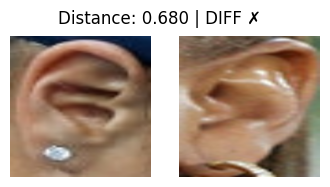

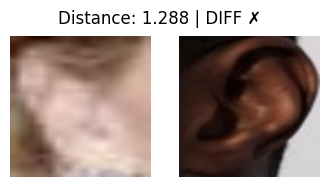

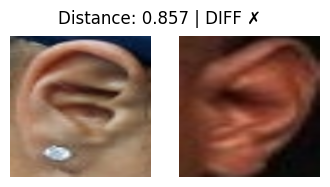

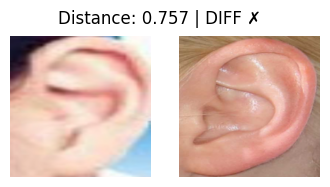

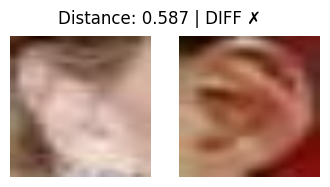

In [15]:
# Kuch images manually dekh
import matplotlib.pyplot as plt

# 5 random negative pairs plot karo aur distance dekho
model.eval()
with torch.no_grad():
    for i in range(5):
        idx1 = random.randint(0, len(val_list)-1)
        idx2 = random.randint(0, len(val_list)-1)
        
        img1 = Image.open(os.path.join(IMG_DIR, val_list[idx1])).convert('RGB')
        img2 = Image.open(os.path.join(IMG_DIR, val_list[idx2])).convert('RGB')
        
        t1 = val_tf(img1).unsqueeze(0).to(DEVICE)
        t2 = val_tf(img2).unsqueeze(0).to(DEVICE)
        
        e1, e2 = model(t1, t2)
        dist = F.pairwise_distance(e1, e2).item()
        
        fig, ax = plt.subplots(1, 2, figsize=(4, 2))
        ax[0].imshow(img1); ax[0].axis('off')
        ax[1].imshow(img2); ax[1].axis('off')
        plt.suptitle(f'Distance: {dist:.3f} | {"SAME ✓" if dist < 0.5 else "DIFF ✗"}')
        plt.show()

In [16]:
# Kitne persons hain aur kitni images per person
from collections import Counter

all_files = sorted(os.listdir(IMG_DIR))

# Filename se person id nikalo — bata kaise hai format
# Jaise 0001_01.webp → person 0001, image 01
print("Sample files:", all_files[:10])

# Agar underscore se split hota hai
persons = [f.split('_')[0] for f in all_files]
counts  = Counter(persons)
print(f"\nTotal persons : {len(counts)}")
print(f"Images per person: {set(counts.values())}")
print(f"Sample: {list(counts.items())[:5]}")

Sample files: ['0001.webp', '0002.webp', '0003.webp', '0004.webp', '0005.webp', '0006.webp', '0007.webp', '0008.webp', '0009.webp', '0010.webp']

Total persons : 1670
Images per person: {1}
Sample: [('0001.webp', 1), ('0002.webp', 1), ('0003.webp', 1), ('0004.webp', 1), ('0005.webp', 1)]


In [18]:
with open(image_list.csv, 'r') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 15: break

NameError: name 'image_list' is not defined

In [19]:
IMG_CSV = os.path.join(BASE, 'image_list.csv')

with open(IMG_CSV, 'r') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 15: break

'0/0001.png\n'
'0/0002.png\n'
'0/0003.png\n'
'0/0004.png\n'
'0/0005.png\n'
'0/0006.png\n'
'0/0007.png\n'
'0/0008.png\n'
'0/0009.png\n'
'0/0010.png\n'
'0/0011.png\n'
'0/0012.png\n'
'0/0013.png\n'
'0/0014.png\n'
'0/0015.png\n'
'0/0016.png\n'
'0/0017.png\n'


In [20]:
# Poore kaggle input mein kya kya hai
for dirname, dirs, files in os.walk('/kaggle/input'):
    depth = dirname.replace('/kaggle/input', '').count(os.sep)
    if depth <= 3:
        print(f"{'  '*depth}{dirname}/")
        for f in files[:5]:
            print(f"{'  '*(depth+1)}{f}")

/kaggle/input/
  /kaggle/input/datasets/
    /kaggle/input/datasets/madhvii0911/
      /kaggle/input/datasets/madhvii0911/uercccc/


KeyboardInterrupt: 

In [21]:
# Numbers dekh — 1670 / 10 = 167 persons hone chahiye
print(f"Total files: {len(all_files)}")
print(f"Agar 10 per person: {len(all_files)//10} persons")
print(f"First 10: {all_files[:10]}")
print(f"Next 10: {all_files[10:20]}")

Total files: 1670
Agar 10 per person: 167 persons
First 10: ['0001.webp', '0002.webp', '0003.webp', '0004.webp', '0005.webp', '0006.webp', '0007.webp', '0008.webp', '0009.webp', '0010.webp']
Next 10: ['0011.webp', '0012.webp', '0013.webp', '0014.webp', '0015.webp', '0016.webp', '0017.webp', '0018.webp', '0019.webp', '0020.webp']
